# Notebook 03 Interpretability: LIME and SHAP for SetFit MPNet

**Goal:** Explain how the best-performing classifier from Notebook 02 makes local predictions, and identify responses where NLP output should be reviewed qualitatively.

**Model being explained:** `SetFit MPNet stronger semantic baseline`, the Notebook 02 winner (`κ = 0.607`, `macro-F1 = 0.711`).

**Important OOF limitation:** Notebook 02's reportable errors are out-of-fold (OOF) predictions, while the saved explainable artifact is the final model trained on all data. This notebook therefore does **not** claim to explain the actual fold-model decision unless the final model prediction matches the saved OOF prediction. For each selected case it records whether the explanation is OOF-compatible or only a final-model proxy.

**Methods:**
- **LIME** (Local Interpretable Model-Agnostic Explanations): primary method. It explains SetFit MPNet through the model's probability function.
- **SHAP** (SHapley Additive exPlanations): secondary method. It is run as a model-agnostic text explainer on the same SetFit probability function for a small example set.
- **Prediction-targeted explanations:** local explanations target the final model's predicted class, not the human class. This is the appropriate target for explaining what the model is doing.
- **LIME–SHAP agreement analysis:** disagreement between local explanation methods flags cases that need human review.
- **Phrase-code triangulation:** phrases from Notebook 03_1 are pooled with LIME and SHAP to identify evidence supported by the human-coded dataset and model explanations.
- **SetFit–human disagreement analysis:** OOF cases where SetFit disagrees with the final qualitative code are inspected as the main qualitative failure mode, with explicit labels showing whether local explanations are fold-compatible or proxy-only.

**Why this design:** Notebook 02 showed that SetFit MPNet substantially outperformed generic sentiment, emotion, and zero-shot models. 


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')  # prevent OpenMP duplicate-runtime segfault (torch+MKL/numba)

import pickle, pathlib, warnings, time, re
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import shap
from lime.lime_text import LimeTextExplainer
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from setfit import SetFitModel
warnings.filterwarnings('ignore')

DATA_DIR = pathlib.Path('data')
SOURCE_OUTPUT_DIR = pathlib.Path('outputs')
OUTPUT_DIR = SOURCE_OUTPUT_DIR / 'broad_candidate_revision'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / 'config.pkl', 'rb') as f:
    cfg = pickle.load(f)
DECISION_CODES   = cfg['DECISION_CODES']
CODE_DEFINITIONS = cfg['CODE_DEFINITIONS']
DEVICE           = cfg['DEVICE']
SEED             = cfg['SEED']
CODE_NAMES       = list(DECISION_CODES.keys())

dm_df  = pd.read_csv(DATA_DIR / 'decision_making.csv')
if 'response_id' not in dm_df.columns:
    dm_df.insert(0, 'response_id', [f'decision_making_{i:04d}' for i in range(len(dm_df))])
if 'source_row_id' not in dm_df.columns:
    dm_df.insert(1, 'source_row_id', dm_df['response_id'])
DOCS   = dm_df['response_text'].tolist()
LABELS = dm_df['label'].values

with open(DATA_DIR / 'classification_results.pkl', 'rb') as f:
    clf_results = pickle.load(f)

with open(DATA_DIR / 'final_setfit_model_info.pkl', 'rb') as f:
    final_setfit_info = pickle.load(f)

BEST_SETFIT_NAME = 'SetFit MPNet stronger semantic baseline 5-fold CV'
BEST_SETFIT_MODEL_ID = final_setfit_info.get('model_id', 'sentence-transformers/all-mpnet-base-v2')
FINAL_SETFIT_MODEL_PATH = pathlib.Path(final_setfit_info.get('model_path', 'models/setfit_mpnet_final'))

DOMAIN_PHRASE_MAP_PATH = DATA_DIR / 'domain_phrase_map.csv'
DOMAIN_PHRASE_CANDIDATES_PATH = SOURCE_OUTPUT_DIR / 'domain_phrase_candidates.csv'

if DOMAIN_PHRASE_MAP_PATH.exists():
    domain_phrase_map = pd.read_csv(DOMAIN_PHRASE_MAP_PATH)
    domain_phrase_map = domain_phrase_map[domain_phrase_map.get('audit_decision', pd.Series('retain', index=domain_phrase_map.index)).eq('retain')].copy()
    print(f'Loaded {len(domain_phrase_map)} audited phrases for sensitivity-analysis reference from {DOMAIN_PHRASE_MAP_PATH}')
else:
    raise FileNotFoundError(
        f'Missing audited phrase map at {DOMAIN_PHRASE_MAP_PATH}. Run Notebook 03_0 before this revision.'
    )

# Primary fair-comparison policy: LIME, phrase-level SHAP, and Notebook 03_1
# evidence all use the same broad Notebook 03_0 candidate vocabulary.
# Raw token-level SHAP remains independent of this post-hoc phrase vocabulary.
PHRASE_VOCABULARY_POLICY = 'broad_candidate_common_vocabulary_v1'
if not DOMAIN_PHRASE_CANDIDATES_PATH.exists():
    raise FileNotFoundError(
        f'Missing broad phrase candidates at {DOMAIN_PHRASE_CANDIDATES_PATH}. Run Notebook 03_0 first.'
    )
domain_phrase_candidates = pd.read_csv(DOMAIN_PHRASE_CANDIDATES_PATH)
if 'phrase_len' not in domain_phrase_candidates.columns:
    domain_phrase_candidates['phrase_len'] = domain_phrase_candidates['phrase'].astype(str).str.split().str.len()
domain_phrase_candidates = domain_phrase_candidates[domain_phrase_candidates['phrase_len'].between(2, 4)].copy()
SHAP_PHRASE_VOCAB = set(domain_phrase_candidates['phrase'].dropna().astype(str).str.lower())
DOMAIN_PHRASES = sorted(SHAP_PHRASE_VOCAB, key=lambda x: len(str(x).split()), reverse=True)
print(
    f'Common broad candidate vocabulary: {len(SHAP_PHRASE_VOCAB)} unique phrases '
    f'from {len(domain_phrase_candidates)} phrase-code rows.'
)

def encode_domain_phrases(text):
    """Join extracted domain phrases with underscores so LIME can perturb them as units."""
    encoded = str(text)
    for phrase in DOMAIN_PHRASES:
        token = str(phrase).replace(' ', '_')
        encoded = re.sub(r'\b' + re.escape(str(phrase)) + r'\b', token, encoded, flags=re.IGNORECASE)
    return encoded

def decode_domain_phrases(text):
    """Return phrase-aware LIME text to normal text before SetFit prediction."""
    return str(text).replace('_', ' ')


# Stopword filtering is applied only to displayed explanation features, not to
# the text passed into SetFit/LIME/SHAP. Keep negations because they carry
# consent meaning, especially for no_consent and refusal-related responses.
NEGATION_WORDS = {'no', 'not', 'never', 'without', 'against', 'nor'}
INTERPRETABILITY_STOPWORDS = (set(ENGLISH_STOP_WORDS) - NEGATION_WORDS) | {
    'it', 'its', 'the', 'and', 'to', 'was', 'were', 'is', 'are', 'am', 'be',
    'been', 'being', 'i', 'me', 'my', 'we', 'us', 'our', 'you', 'your', 'so',
    'very', 'really', 'just', 'also', 'would', 'could', 'should', 'did', 'had',
    'have', 'has', 'for', 'of', 'in', 'on', 'at', 'by', 'with', 'as', 'that',
    'this', 'there', 'then', 'than', 'from', 'they', 'them', 'their', 'he',
    'she', 'his', 'her', 'or', 'but', 'if', 'because', 'when', 'while', 'during'
}

def clean_explanation_token(token):
    token = str(token).strip().lower().replace('Ġ', '')
    token = re.sub(r"^[^a-z0-9_']+|[^a-z0-9_']+$", '', token)
    return token

def display_explanation_token(token):
    return clean_explanation_token(token).replace('_', ' ')

def is_interpretable_token(token):
    token = clean_explanation_token(token)
    if '_' in token:
        parts = [p for p in token.split('_') if p]
        return len(parts) >= 2 and any(p not in INTERPRETABILITY_STOPWORDS or p in NEGATION_WORDS for p in parts)
    if len(token) < 3:
        return False
    if token.startswith('##'):
        return False
    if token in INTERPRETABILITY_STOPWORDS:
        return False
    if token.isnumeric():
        return False
    return True

def top_interpretable_lime_features(exp, label, top_n=8):
    features = []
    for word, weight in exp.as_list(label=label):
        token = clean_explanation_token(word)
        if is_interpretable_token(token):
            features.append((display_explanation_token(token), weight))
    return features[:top_n]


def canonical_explanation_words(token):
    """Return normalized words for a SHAP token/chunk without dropping stopwords."""
    token = str(token).lower().replace('Ġ', ' ')
    token = re.sub(r"[^a-z0-9'\s_]+", ' ', token.replace('_', ' '))
    return [w for w in re.sub(r'\s+', ' ', token).strip().split() if w]


def canonical_phrase_text(text):
    return ' '.join(canonical_explanation_words(text))


SHAP_PHRASE_VOCAB = {canonical_phrase_text(p) for p in SHAP_PHRASE_VOCAB if canonical_phrase_text(p)}


def shap_phrase_scores_for_example(shap_tokens, shap_vals, phrase_vocab=SHAP_PHRASE_VOCAB, min_n=2, max_n=4):
    """Aggregate SHAP attributions into contiguous Notebook 03_0 2-4 gram phrases.

    This preserves original SHAP token order and does not remove stopwords before
    rebuilding n-grams. Earlier stopword filtering could accidentally join words
    that were not adjacent in the source text; this version only scores phrases
    found as contiguous spans in the SHAP token stream.
    """
    words = []
    values = []
    for tok, val in zip(shap_tokens, shap_vals):
        parts = canonical_explanation_words(tok)
        if not parts:
            continue
        split_value = float(val) / len(parts)
        for part in parts:
            words.append(part)
            values.append(split_value)

    phrase_scores = {}
    for start in range(len(words)):
        for n in range(min_n, max_n + 1):
            end = start + n
            if end > len(words):
                continue
            phrase = ' '.join(words[start:end])
            if phrase not in phrase_vocab:
                continue
            score = sum(values[start:end])
            phrase_scores[phrase] = phrase_scores.get(phrase, 0.0) + score
    return phrase_scores

print(f'Loaded {len(DOCS)} docs')
print(f'Device: {DEVICE}')
print('Notebook 02 winner:')
print(clf_results[BEST_SETFIT_NAME])
print(f'Final SetFit artifact from Notebook 02: {FINAL_SETFIT_MODEL_PATH}')


c:\Users\pruth\anaconda3\envs\thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 32 audited phrases for sensitivity-analysis reference from data\domain_phrase_map.csv
Common broad candidate vocabulary: 625 unique phrases from 1109 phrase-code rows.
Loaded 278 docs
Device: cuda
Notebook 02 winner:
{'preds': array([1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 1,
       0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 1, 2, 2, 2, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2,
       2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2,
       2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2,
       2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 2,

## 1. Load the final SetFit MPNet classifier saved by Notebook 02

The cross-validated SetFit MPNet predictions from Notebook 02 remain the reportable evaluation result. For interpretability, this notebook loads the final full-data SetFit MPNet artifact saved by Notebook 02 at `models/setfit_mpnet_final`. This avoids retraining and keeps the LIME/SHAP explanations tied to the selected classifier artifact.


In [2]:
print(f'Loading final SetFit model from Notebook 02: {FINAL_SETFIT_MODEL_PATH}')
if not FINAL_SETFIT_MODEL_PATH.exists():
    raise FileNotFoundError(f'Final SetFit model not found at {FINAL_SETFIT_MODEL_PATH}.')

setfit_model = SetFitModel.from_pretrained(str(FINAL_SETFIT_MODEL_PATH), device=DEVICE)
setfit_model.model_body.to(DEVICE)

def setfit_predict_proba(texts):
    probs = setfit_model.predict_proba(list(texts))
    return probs.detach().cpu().numpy() if hasattr(probs, 'detach') else np.asarray(probs)

def setfit_predict_label(texts):
    return np.argmax(setfit_predict_proba(texts), axis=1)

if BEST_SETFIT_NAME not in clf_results:
    raise KeyError(f'Saved OOF result not found: {BEST_SETFIT_NAME}')
setfit_cv_preds = np.asarray(clf_results[BEST_SETFIT_NAME]['preds']).astype(int)
saved_true = np.asarray(clf_results[BEST_SETFIT_NAME]['true']).astype(int)
if len(setfit_cv_preds) != len(dm_df) or not np.array_equal(saved_true, LABELS):
    raise ValueError('Notebook 02 OOF predictions do not align with the immutable response table.')

final_preds = setfit_predict_label(DOCS).astype(int)
explanation_target_preds = final_preds.copy()
dm_df['pred_setfit_oof'] = setfit_cv_preds
dm_df['pred_setfit_final_explainer'] = final_preds
dm_df['explanation_target_label'] = explanation_target_preds
dm_df['explanation_target_code'] = [CODE_NAMES[i] for i in explanation_target_preds]
dm_df['explanation_matches_oof_prediction'] = explanation_target_preds == setfit_cv_preds
dm_df['explanation_scope'] = np.where(
    dm_df['explanation_matches_oof_prediction'],
    'final-model proxy aligned with OOF prediction',
    'final-model proxy differs from OOF prediction',
)
print(f'OOF accuracy loaded from Notebook 02: {(setfit_cv_preds == LABELS).mean():.3f}')
print(f'Final-model apparent training agreement: {(final_preds == LABELS).mean():.3f}')
print(f'Final proxy matches OOF prediction: {(final_preds == setfit_cv_preds).sum()}/{len(dm_df)}')
print('Guardrail: all LIME/SHAP explanations below describe the saved full-data model. Even when its class matches an OOF prediction, it is an aligned proxy—not an explanation of the fold-specific OOF model.')


Loading final SetFit model from Notebook 02: models\setfit_mpnet_final
OOF accuracy loaded from Notebook 02: 0.763
Final-model apparent training agreement: 1.000
Final proxy matches OOF prediction: 212/278
Guardrail: all LIME/SHAP explanations below describe the saved full-data model. Even when its class matches an OOF prediction, it is an aligned proxy—not an explanation of the fold-specific OOF model.


## 2. Full-corpus, stratified explanation scope

LIME and SHAP are run for **all 278 decision-making responses**. Stratification is used in reporting rather than subsampling: results are broken down by final human code and by whether the Notebook 02 out-of-fold prediction was correct. Only a small, deterministic stratified preview is displayed inline so the notebook remains readable; every response contributes to the saved tables and aggregate figures.


In [3]:
# -- Full-corpus explanation scope with stratified reporting --------------------
explain_examples = list(range(len(DOCS)))
explain_docs = [DOCS[i] for i in explain_examples]

scope_rows = []
display_examples = []
for code_idx, code_name in enumerate(CODE_NAMES):
    for is_correct, status in [(True, 'correct'), (False, 'incorrect')]:
        indices = np.where((LABELS == code_idx) & ((setfit_cv_preds == LABELS) == is_correct))[0]
        scope_rows.append({
            'true_code': code_name,
            'prediction_status': status,
            'n_responses': int(len(indices)),
            'all_explained': True,
        })
        if len(indices):
            display_examples.append(int(indices[0]))

display_examples = list(dict.fromkeys(display_examples))
selection_df = pd.DataFrame(scope_rows)

print(f'Full-corpus explanation scope: {len(explain_examples)} / {len(DOCS)} responses')
print('Every response is included; strata below are reporting groups, not samples.')
print(selection_df.to_string(index=False))
print(f'Inline preview limited to {len(display_examples)} deterministic cases (up to one per code x correctness stratum).')


Full-corpus explanation scope: 278 / 278 responses
Every response is included; strata below are reporting groups, not samples.
         true_code prediction_status  n_responses  all_explained
voluntary_informed           correct           21           True
voluntary_informed         incorrect           15           True
 feeling_pressured           correct           55           True
 feeling_pressured         incorrect           25           True
 insufficient_info           correct          126           True
 insufficient_info         incorrect           19           True
     too_much_info           correct            7           True
     too_much_info         incorrect            2           True
        no_consent           correct            3           True
        no_consent         incorrect            5           True
Inline preview limited to 10 deterministic cases (up to one per code x correctness stratum).


## 3. LIME — full-corpus local explanations for SetFit MPNet

Phrase-aware LIME is run on every response using Notebook 03_0's retained phrase map. Results are checkpointed after small batches, so an interrupted long run resumes without discarding completed explanations. LIME still explains the saved final all-data model; OOF correctness is used only for stratified reporting.


In [4]:
# -- Phrase-aware LIME over the full corpus, with resumable checkpoints --------
import hashlib

LIME_NUM_FEATURES = 30
LIME_NUM_SAMPLES = 500
CHECKPOINT_EVERY = 10
CHECKPOINT_DIR = DATA_DIR / 'interpretability_checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)
LIME_CHECKPOINT_PATH = CHECKPOINT_DIR / 'lime_full_corpus_broad_candidate_common_vocab.pkl'

phrase_vocabulary_fingerprint = hashlib.sha256(
    '|'.join(sorted(SHAP_PHRASE_VOCAB)).encode('utf-8')
).hexdigest()
corpus_fingerprint = hashlib.sha256(
    ('\n'.join(map(str, DOCS)) +
     f'|{FINAL_SETFIT_MODEL_PATH}|{LIME_NUM_FEATURES}|{LIME_NUM_SAMPLES}|{phrase_vocabulary_fingerprint}').encode('utf-8')
).hexdigest()

lime_explainer = LimeTextExplainer(
    class_names=CODE_NAMES,
    feature_selection='auto',
    random_state=SEED,
)

def setfit_predict_proba_for_lime(texts):
    decoded_texts = [decode_domain_phrases(t) for t in texts]
    return setfit_predict_proba(decoded_texts)

def checkpoint_candidates(path):
    candidates = [path, path.with_suffix(path.suffix + '.tmp')]
    candidates.extend(path.parent.glob(f'{path.stem}_*{path.suffix}'))
    existing = {candidate for candidate in candidates if candidate.exists()}
    return sorted(existing, key=lambda candidate: candidate.stat().st_mtime, reverse=True)

def atomic_pickle_dump(obj, path):
    # Immutable numbered checkpoint files avoid Windows/OneDrive replacement locks.
    progress = max([
        len(value) for key, value in obj.items()
        if key in {'lime_explanations', 'shap_values_by_doc'} and hasattr(value, '__len__')
    ] + [0])
    version_path = path.with_name(f'{path.stem}_{progress:04d}{path.suffix}')
    with open(version_path, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    return version_path

lime_explanations = {}
lime_encoded_docs = {}
for checkpoint_path in checkpoint_candidates(LIME_CHECKPOINT_PATH):
    try:
        with open(checkpoint_path, 'rb') as f:
            saved = pickle.load(f)
        if saved.get('fingerprint') == corpus_fingerprint:
            lime_explanations = saved.get('lime_explanations', {})
            lime_encoded_docs = saved.get('lime_encoded_docs', {})
            print(f'Resuming LIME checkpoint {checkpoint_path.name}: {len(lime_explanations)} completed responses')
            break
    except Exception as exc:
        print(f'Skipping unreadable LIME checkpoint {checkpoint_path.name}: {exc}')

pending = [idx for idx in explain_examples if idx not in lime_explanations]
print(f'Running phrase-aware LIME for {len(pending)} pending of {len(explain_examples)} total responses...')
print(f'Domain phrases available: {len(DOMAIN_PHRASES)}; num_samples={LIME_NUM_SAMPLES}')
t0 = time.time()

for run_i, doc_idx in enumerate(pending, 1):
    doc = DOCS[doc_idx]
    encoded_doc = encode_domain_phrases(doc)
    lime_encoded_docs[doc_idx] = encoded_doc
    target_code_idx = int(explanation_target_preds[doc_idx])
    lime_explanations[doc_idx] = lime_explainer.explain_instance(
        encoded_doc,
        setfit_predict_proba_for_lime,
        num_features=LIME_NUM_FEATURES,
        num_samples=LIME_NUM_SAMPLES,
        labels=[target_code_idx],
    )
    if run_i % CHECKPOINT_EVERY == 0 or run_i == len(pending):
        atomic_pickle_dump({
            'fingerprint': corpus_fingerprint,
            'lime_explanations': lime_explanations,
            'lime_encoded_docs': lime_encoded_docs,
        }, LIME_CHECKPOINT_PATH)
        print(f'  LIME checkpoint: {len(lime_explanations)}/{len(explain_examples)} complete')

missing_lime = sorted(set(explain_examples) - set(lime_explanations))
if missing_lime:
    raise RuntimeError(f'LIME did not complete all responses: {missing_lime[:10]}')
print(f'LIME full-corpus run complete in {time.time()-t0:.1f}s ({len(lime_explanations)} responses).')


Resuming LIME checkpoint lime_full_corpus_broad_candidate_common_vocab_0278.pkl: 278 completed responses
Running phrase-aware LIME for 0 pending of 278 total responses...
Domain phrases available: 625; num_samples=500
LIME full-corpus run complete in 0.0s (278 responses).


In [5]:
# -- LIME: compact stratified preview; all cases remain in saved outputs --------
for doc_idx in display_examples:
    exp = lime_explanations[doc_idx]
    true_code_idx = int(LABELS[doc_idx])
    target_code_idx = int(explanation_target_preds[doc_idx])
    true_code = CODE_NAMES[true_code_idx]
    target_code = CODE_NAMES[target_code_idx]
    cv_pred = CODE_NAMES[int(setfit_cv_preds[doc_idx])]
    status = 'correct' if true_code_idx == int(setfit_cv_preds[doc_idx]) else 'incorrect'
    features = top_interpretable_lime_features(exp, target_code_idx, top_n=8)

    print(f'\n-- LIME preview: doc_idx={doc_idx} | human={true_code} | OOF={cv_pred} ({status}) | final target={target_code} --')
    for word, weight in features:
        direction = 'SUPPORTS' if weight > 0 else 'OPPOSES'
        print(f'  {word:35s} {weight:+.4f}  {direction}')

print(f'\nDisplayed {len(display_examples)} stratified previews; analysed {len(lime_explanations)} responses in total.')



-- LIME preview: doc_idx=2 | human=voluntary_informed | OOF=voluntary_informed (correct) | final target=voluntary_informed --
  glad                                +0.5523  SUPPORTS
  wanted to avoid                     -0.1087  OPPOSES
  opportunity                         +0.0557  SUPPORTS
  vbac                                -0.0294  OPPOSES
  scenario                            -0.0276  OPPOSES
  needed                              +0.0255  SUPPORTS
  attempt                             +0.0117  SUPPORTS

-- LIME preview: doc_idx=0 | human=voluntary_informed | OOF=feeling_pressured (incorrect) | final target=voluntary_informed --
  wanted to induce                    +0.0289  SUPPORTS
  asked                               +0.0259  SUPPORTS
  wait                                +0.0057  SUPPORTS

-- LIME preview: doc_idx=36 | human=feeling_pressured | OOF=feeling_pressured (correct) | final target=feeling_pressured --
  forced                              +0.3841  SUPPORTS
  uncom

## 4. SHAP — full-corpus secondary explanations for SetFit MPNet

Model-agnostic SHAP uses the same SetFit probability function as LIME and is run response-by-response for the full corpus. Compact serializable token/value arrays are checkpointed, avoiding a single large in-memory call and allowing safe resumption.


In [6]:
# -- SHAP over the full corpus, response-by-response with checkpoints -----------
SHAP_MAX_EVALS = 500
SHAP_CHECKPOINT_EVERY = 5
SHAP_CHECKPOINT_PATH = CHECKPOINT_DIR / 'shap_full_corpus.pkl'
shap_fingerprint = hashlib.sha256(
    ('\n'.join(map(str, DOCS)) + f'|{FINAL_SETFIT_MODEL_PATH}|{SHAP_MAX_EVALS}').encode('utf-8')
).hexdigest()

explainer = shap.Explainer(
    setfit_predict_proba,
    masker=shap.maskers.Text(),
    output_names=CODE_NAMES,
)

shap_values_by_doc = {}
for checkpoint_path in checkpoint_candidates(SHAP_CHECKPOINT_PATH):
    try:
        with open(checkpoint_path, 'rb') as f:
            saved = pickle.load(f)
        if saved.get('fingerprint') == shap_fingerprint:
            shap_values_by_doc = saved.get('shap_values_by_doc', {})
            print(f'Resuming SHAP checkpoint {checkpoint_path.name}: {len(shap_values_by_doc)} completed responses')
            break
    except Exception as exc:
        print(f'Skipping unreadable SHAP checkpoint {checkpoint_path.name}: {exc}')

pending = [idx for idx in explain_examples if idx not in shap_values_by_doc]
print(f'Running SHAP for {len(pending)} pending of {len(explain_examples)} total responses...')
print(f'max_evals={SHAP_MAX_EVALS}; checkpoints every {SHAP_CHECKPOINT_EVERY} responses')
t0 = time.time()

for run_i, doc_idx in enumerate(pending, 1):
    sv = explainer([DOCS[doc_idx]], max_evals=SHAP_MAX_EVALS)
    one = sv[0]
    shap_values_by_doc[doc_idx] = {
        'data': np.asarray(one.data, dtype=object),
        'values': np.asarray(one.values, dtype=float),
        'base_values': np.asarray(one.base_values, dtype=float),
    }
    if run_i % SHAP_CHECKPOINT_EVERY == 0 or run_i == len(pending):
        atomic_pickle_dump({
            'fingerprint': shap_fingerprint,
            'shap_values_by_doc': shap_values_by_doc,
        }, SHAP_CHECKPOINT_PATH)
        print(f'  SHAP checkpoint: {len(shap_values_by_doc)}/{len(explain_examples)} complete')

missing_shap = sorted(set(explain_examples) - set(shap_values_by_doc))
if missing_shap:
    raise RuntimeError(f'SHAP did not complete all responses: {missing_shap[:10]}')
print(f'SHAP full-corpus run complete in {time.time()-t0:.1f}s ({len(shap_values_by_doc)} responses).')


Resuming SHAP checkpoint shap_full_corpus_0278.pkl: 278 completed responses
Running SHAP for 0 pending of 278 total responses...
max_evals=500; checkpoints every 5 responses
SHAP full-corpus run complete in 0.0s (278 responses).


In [7]:
# -- SHAP: compact stratified preview ------------------------------------------
for doc_idx in display_examples:
    item = shap_values_by_doc[doc_idx]
    target_code_idx = int(explanation_target_preds[doc_idx])
    true_code = CODE_NAMES[int(LABELS[doc_idx])]
    cv_pred = CODE_NAMES[int(setfit_cv_preds[doc_idx])]
    target_code = CODE_NAMES[target_code_idx]
    status = 'correct' if int(LABELS[doc_idx]) == int(setfit_cv_preds[doc_idx]) else 'incorrect'
    token_scores = []
    for token, value in zip(item['data'], item['values'][:, target_code_idx]):
        token_clean = clean_explanation_token(token)
        if is_interpretable_token(token_clean):
            token_scores.append((display_explanation_token(token_clean), float(value)))
    token_scores = sorted(token_scores, key=lambda x: abs(x[1]), reverse=True)[:8]
    print(f'\n-- SHAP preview: doc_idx={doc_idx} | human={true_code} | OOF={cv_pred} ({status}) | final target={target_code} --')
    for token, value in token_scores:
        direction = 'SUPPORTS' if value > 0 else 'OPPOSES'
        print(f'  {token:35s} {value:+.4f}  {direction}')

print(f'\nDisplayed {len(display_examples)} stratified previews; analysed {len(shap_values_by_doc)} responses in total.')



-- SHAP preview: doc_idx=2 | human=voluntary_informed | OOF=voluntary_informed (correct) | final target=voluntary_informed --
  glad                                +0.4534  SUPPORTS
  opportunity                         +0.1461  SUPPORTS
  avoid                               -0.1180  OPPOSES
  scenario                            -0.1093  OPPOSES
  vbac                                +0.0716  SUPPORTS
  wanted                              -0.0561  OPPOSES
  needed                              +0.0533  SUPPORTS
  attempt                             +0.0021  SUPPORTS

-- SHAP preview: doc_idx=0 | human=voluntary_informed | OOF=feeling_pressured (incorrect) | final target=voluntary_informed --
  asked                               +0.1323  SUPPORTS
  induce                              +0.0990  SUPPORTS
  wait                                -0.0864  OPPOSES
  wanted                              +0.0737  SUPPORTS

-- SHAP preview: doc_idx=36 | human=feeling_pressured | OOF=feeling_pressure

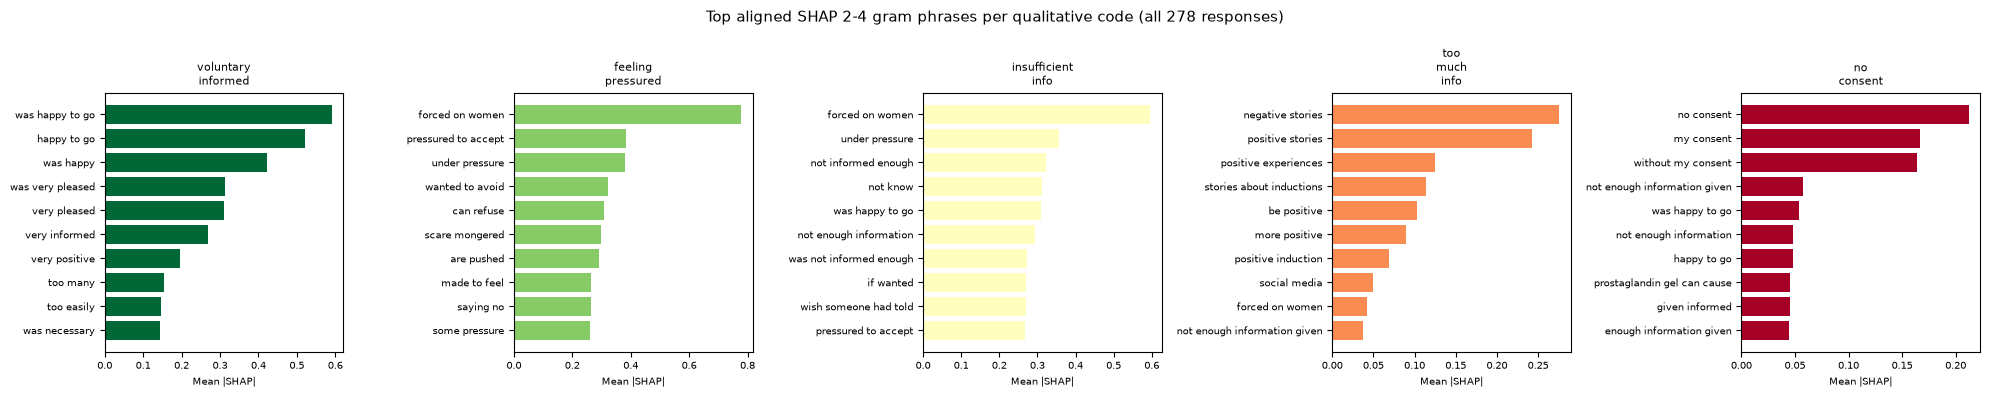

Full-corpus SHAP phrase vocabulary size: 625

voluntary_informed:
  was happy to go                     0.5914
  happy to go                         0.5214
  was happy                           0.4225
  was very pleased                    0.3129
  very pleased                        0.3092
  very informed                       0.2687
  very positive                       0.1959
  too many                            0.1530

feeling_pressured:
  forced on women                     0.7782
  pressured to accept                 0.3831
  under pressure                      0.3797
  wanted to avoid                     0.3213
  can refuse                          0.3071
  scare mongered                      0.2977
  are pushed                          0.2920
  made to feel                        0.2652

insufficient_info:
  forced on women                     0.5962
  under pressure                      0.3570
  not informed enough                 0.3234
  not know                            0

In [8]:
# -- SHAP summary: full-corpus tokens and aligned 2-4 gram phrases ------------
token_shap_by_class = defaultdict(lambda: defaultdict(list))
phrase_shap_by_class = defaultdict(lambda: defaultdict(list))
phrase_shap_by_example = {}

for doc_idx in explain_examples:
    item = shap_values_by_doc[int(doc_idx)]
    tokens = item['data']
    all_values = item['values']
    phrase_shap_by_example[int(doc_idx)] = {}
    for class_idx, code_name in enumerate(CODE_NAMES):
        values = all_values[:, class_idx]
        for token, val in zip(tokens, values):
            token_clean = clean_explanation_token(token)
            if is_interpretable_token(token_clean):
                token_shap_by_class[code_name][display_explanation_token(token_clean)].append(abs(float(val)))

        phrase_scores = shap_phrase_scores_for_example(tokens, values)
        phrase_shap_by_example[int(doc_idx)][code_name] = phrase_scores
        for phrase, score in phrase_scores.items():
            phrase_shap_by_class[code_name][phrase].append(abs(float(score)))

fig, axes = plt.subplots(1, len(CODE_NAMES), figsize=(20, 4))
for i, code in enumerate(CODE_NAMES):
    phrase_means = {phrase: np.mean(vals) for phrase, vals in phrase_shap_by_class[code].items()}
    top = sorted(phrase_means.items(), key=lambda x: x[1], reverse=True)[:10]
    if not top:
        axes[i].set_title(code.replace('_', '\n'), fontsize=8)
        axes[i].text(0.5, 0.5, 'No matched\n2-4 gram phrases', ha='center', va='center', fontsize=8)
        axes[i].axis('off')
        continue
    phrases = [x[0] for x in top][::-1]
    scores = [x[1] for x in top][::-1]
    axes[i].barh(phrases, scores, color=plt.cm.RdYlGn_r(i / max(1, len(CODE_NAMES)-1)))
    axes[i].set_title(code.replace('_', '\n'), fontsize=8)
    axes[i].set_xlabel('Mean |SHAP|', fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Top aligned SHAP 2-4 gram phrases per qualitative code (all 278 responses)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_top_phrases.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Full-corpus SHAP phrase vocabulary size: {len(SHAP_PHRASE_VOCAB)}')
for code in CODE_NAMES:
    phrase_means = {phrase: np.mean(vals) for phrase, vals in phrase_shap_by_class[code].items()}
    top = sorted(phrase_means.items(), key=lambda x: x[1], reverse=True)[:8]
    print(f'\n{code}:')
    for phrase, score in top:
        print(f'  {phrase:35s} {score:.4f}')
    if not top:
        print('  No aligned broad candidate phrases matched.')


## 5. Full-corpus LIME-SHAP agreement analysis

Both explainers use the same 2- to 4-word canonical phrase policy. Per-response agreement is summarized across the entire corpus and stratified by final human code and Notebook 02 OOF correctness. Exact overlap and Jaccard are primary because Spearman correlation requires at least three shared phrases and is often non-estimable.


LIME-SHAP agreement analysis for SetFit MPNet (aligned 2-4 gram phrase features only):
Explanations target the saved final model; OOF-aligned means class agreement only, not a fold-model explanation.
         true_code prediction_status  n_responses  responses_with_exact_overlap  median_shared_phrases  mean_exact_jaccard  median_exact_jaccard  estimable_spearman  mean_spearman  exact_overlap_rate
 feeling_pressured           correct           55                            52                    3.0            0.522261              0.500000                  33       0.505411            0.945455
 feeling_pressured         incorrect           25                            22                    2.0            0.527464              0.500000                  11       0.272727            0.880000
 insufficient_info           correct          126                           115                    2.0            0.563898              0.500000                  57       0.428906            0.912698


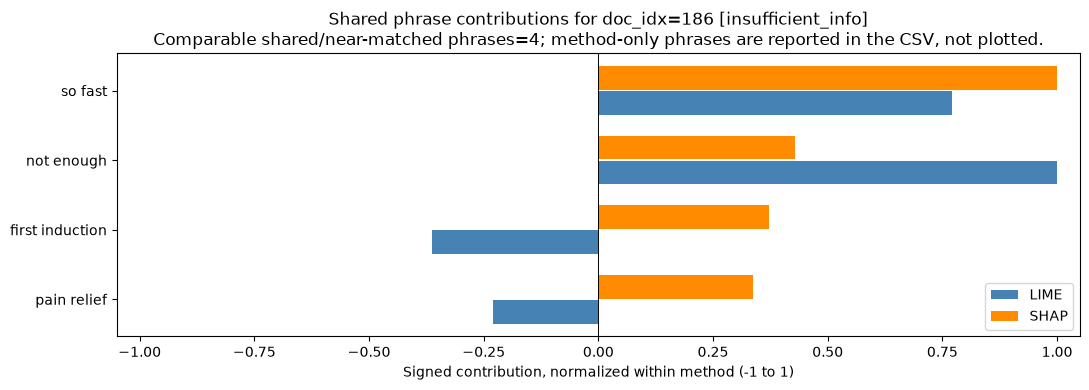

In [18]:
# ── Agreement metric and side-by-side comparison using aligned phrases ───────
agreement_scores = []
agreement_details = []

for i, doc_idx in enumerate(explain_examples):
    true_code_idx = int(LABELS[doc_idx])
    target_code_idx = int(explanation_target_preds[doc_idx])
    true_code_name = CODE_NAMES[true_code_idx]
    target_code_name = CODE_NAMES[target_code_idx]
    cv_pred_idx = int(setfit_cv_preds[doc_idx])
    cv_pred_name = CODE_NAMES[cv_pred_idx]
    oof_compatible = bool(target_code_idx == cv_pred_idx)

    if doc_idx not in lime_explanations:
        continue

    lime_feats = top_interpretable_lime_features(lime_explanations[doc_idx], target_code_idx, top_n=20)
    lime_phrase_scores = {w: abs(s) for w, s in lime_feats if len(str(w).split()) >= 2}

    shap_phrase_scores_signed = phrase_shap_by_example.get(int(doc_idx), {}).get(target_code_name, {})
    shap_phrase_scores = {p: abs(s) for p, s in shap_phrase_scores_signed.items()}

    common_phrases = set(lime_phrase_scores.keys()) & set(shap_phrase_scores.keys())

    if len(common_phrases) >= 3:
        lime_ranks = [lime_phrase_scores.get(p, 0) for p in common_phrases]
        shap_ranks = [shap_phrase_scores.get(p, 0) for p in common_phrases]
        rho, p = spearmanr(lime_ranks, shap_ranks)
    else:
        rho, p = float('nan'), float('nan')

    agreement_scores.append(rho)
    agreement_details.append({
        'doc_idx':       doc_idx,
        'true_code':     true_code_name,
        'setfit_cv_pred': cv_pred_name,
        'final_explainer_pred': target_code_name,
        'explanation_target': target_code_name,
        'explanation_target_type': 'final_model_predicted_class',
        'oof_error': bool(true_code_idx != cv_pred_idx),
        'explanation_matches_oof_prediction': oof_compatible,
        'explanation_scope': 'OOF-aligned final-model proxy' if oof_compatible else 'OOF-mismatched final-model proxy',
        'spearman_rho':  rho,
        'p_value':       p,
        'n_common':      len(common_phrases),
        'lime_top3':     sorted(lime_phrase_scores.keys(), key=lambda w: lime_phrase_scores[w], reverse=True)[:3],
        'shap_top3':     sorted(shap_phrase_scores.keys(), key=lambda w: shap_phrase_scores[w], reverse=True)[:3],
        'exact_jaccard_topk': len(common_phrases) / len(set(lime_phrase_scores) | set(shap_phrase_scores)) if (set(lime_phrase_scores) | set(shap_phrase_scores)) else np.nan,
        'flag_for_review': len(common_phrases) == 0 or true_code_idx != cv_pred_idx or not oof_compatible,
    })

agreement_df = pd.DataFrame(agreement_details)
agreement_df['prediction_status'] = np.where(agreement_df['oof_error'], 'incorrect', 'correct')
agreement_stratified_df = (
    agreement_df.groupby(['true_code', 'prediction_status'], dropna=False)
    .agg(
        n_responses=('doc_idx', 'size'),
        responses_with_exact_overlap=('n_common', lambda s: int((pd.to_numeric(s, errors='coerce').fillna(0) > 0).sum())),
        median_shared_phrases=('n_common', 'median'),
        mean_exact_jaccard=('exact_jaccard_topk', 'mean'),
        median_exact_jaccard=('exact_jaccard_topk', 'median'),
        estimable_spearman=('spearman_rho', lambda s: int(pd.to_numeric(s, errors='coerce').notna().sum())),
        mean_spearman=('spearman_rho', 'mean'),
    )
    .reset_index()
)
agreement_stratified_df['exact_overlap_rate'] = (
    agreement_stratified_df['responses_with_exact_overlap'] / agreement_stratified_df['n_responses']
)
agreement_stratified_df.to_csv(OUTPUT_DIR / 'shap_lime_agreement_stratified.csv', index=False)
print('LIME-SHAP agreement analysis for SetFit MPNet (aligned 2-4 gram phrase features only):')
print('Explanations target the saved final model; OOF-aligned means class agreement only, not a fold-model explanation.')
print(agreement_stratified_df.to_string(index=False))

print()
print(f'Flagged for human review: {agreement_df["flag_for_review"].sum()} / {len(agreement_df)} examples')
print(f'OOF-compatible explanation examples: {agreement_df["explanation_matches_oof_prediction"].sum()} / {len(agreement_df)}')
print()
print('Thesis point: exact top-phrase overlap is reported with Jaccard because rank correlation is usually non-estimable. All explanations remain final-model proxies.')

# Aligned comparison plot: use shared/near-shared phrase rows and normalized scores.
def phrases_are_near_match(a, b):
    a_tokens = str(a).lower().split()
    b_tokens = str(b).lower().split()
    if not a_tokens or not b_tokens:
        return False
    a_text = ' '.join(a_tokens)
    b_text = ' '.join(b_tokens)
    if a_text == b_text:
        return True
    if len(a_tokens) >= 2 and len(b_tokens) >= 2:
        return a_text in b_text or b_text in a_text
    return False


def build_aligned_phrase_comparison(lime_scores_signed, shap_scores_signed, top_n=12):
    lime_top = sorted(lime_scores_signed.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    shap_top = sorted(shap_scores_signed.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]

    rows = []
    used_shap = set()
    for lime_phrase, lime_value in lime_top:
        best_match = None
        best_match_len = -1
        for shap_phrase, shap_value in shap_top:
            if shap_phrase in used_shap:
                continue
            if phrases_are_near_match(lime_phrase, shap_phrase):
                match_len = min(len(str(lime_phrase).split()), len(str(shap_phrase).split()))
                if match_len > best_match_len:
                    best_match = (shap_phrase, shap_value)
                    best_match_len = match_len
        if best_match is None:
            rows.append({
                'display_phrase': lime_phrase,
                'lime_phrase': lime_phrase,
                'shap_phrase': '',
                'lime_raw': float(lime_value),
                'shap_raw': 0.0,
                'match_type': 'LIME only',
            })
        else:
            shap_phrase, shap_value = best_match
            used_shap.add(shap_phrase)
            display_phrase = lime_phrase if lime_phrase == shap_phrase else f'{lime_phrase} / {shap_phrase}'
            rows.append({
                'display_phrase': display_phrase,
                'lime_phrase': lime_phrase,
                'shap_phrase': shap_phrase,
                'lime_raw': float(lime_value),
                'shap_raw': float(shap_value),
                'match_type': 'matched' if lime_phrase == shap_phrase else 'near match',
            })

    for shap_phrase, shap_value in shap_top:
        if shap_phrase in used_shap:
            continue
        rows.append({
            'display_phrase': shap_phrase,
            'lime_phrase': '',
            'shap_phrase': shap_phrase,
            'lime_raw': 0.0,
            'shap_raw': float(shap_value),
            'match_type': 'SHAP only',
        })

    aligned = pd.DataFrame(rows)
    if aligned.empty:
        return aligned

    aligned['importance'] = aligned[['lime_raw', 'shap_raw']].abs().max(axis=1)
    aligned = aligned.sort_values('importance', ascending=False).head(top_n).copy()
    lime_scale = aligned['lime_raw'].abs().max()
    shap_scale = aligned['shap_raw'].abs().max()
    aligned['lime_normalized'] = aligned['lime_raw'] / lime_scale if lime_scale > 0 else 0.0
    aligned['shap_normalized'] = aligned['shap_raw'] / shap_scale if shap_scale > 0 else 0.0
    return aligned.sort_values('importance', ascending=True).reset_index(drop=True)


# Select a different eligible example each time this cell/notebook is run.
# No fixed seed is supplied, so NumPy draws fresh entropy for every execution.
plot_candidates = agreement_df.copy()
plot_candidates['n_common_sort'] = plot_candidates['n_common'].fillna(0)
random_plot_candidates = plot_candidates[plot_candidates['n_common_sort'] > 0].reset_index(drop=True)
if random_plot_candidates.empty:
    raise RuntimeError('No response has an exact LIME-SHAP phrase overlap to plot.')

random_generator = np.random.default_rng()
random_position = int(random_generator.integers(0, len(random_plot_candidates)))
example_row = random_plot_candidates.iloc[random_position]

doc_idx   = int(example_row['doc_idx'])
code_idx  = int(explanation_target_preds[doc_idx])
code_name = CODE_NAMES[code_idx]
print(
    f'Random graph example: doc_idx={doc_idx}, target={code_name}, '
    f'exact shared phrases={int(example_row["n_common_sort"])}'
)

lime_feats = top_interpretable_lime_features(lime_explanations[doc_idx], code_idx, top_n=30)
lime_phrase_scores_signed = {w: s for w, s in lime_feats if len(str(w).split()) >= 2}
shap_phrase_scores_signed = phrase_shap_by_example.get(doc_idx, {}).get(code_name, {})

aligned_plot_df = build_aligned_phrase_comparison(
    lime_phrase_scores_signed,
    shap_phrase_scores_signed,
    top_n=12,
)
aligned_plot_df.insert(0, 'doc_idx', doc_idx)
aligned_plot_df.insert(1, 'code_name', code_name)
aligned_plot_df.to_csv(OUTPUT_DIR / 'shap_lime_aligned_phrase_example.csv', index=False)
aligned_plot_df.to_csv(
    OUTPUT_DIR / f'shap_lime_aligned_phrase_example_doc_{doc_idx:04d}.csv', index=False
)

shared_plot_df = aligned_plot_df[aligned_plot_df['match_type'].isin(['matched', 'near match'])].copy()
fig, ax = plt.subplots(figsize=(11, max(4, 0.55 * max(1, len(shared_plot_df)))))
if shared_plot_df.empty:
    ax.text(0.5, 0.5, 'No shared or near-matched phrases in this example', ha='center', va='center', fontsize=12)
    ax.axis('off')
else:
    y = np.arange(len(shared_plot_df))
    ax.barh(y - 0.18, shared_plot_df['lime_normalized'], height=0.34, color='steelblue', label='LIME')
    ax.barh(y + 0.18, shared_plot_df['shap_normalized'], height=0.34, color='darkorange', label='SHAP')
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(shared_plot_df['display_phrase'])
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel('Signed contribution, normalized within method (-1 to 1)')
    ax.legend(loc='lower right')
    for row_idx, row in shared_plot_df.reset_index(drop=True).iterrows():
        if row['match_type'] == 'near match':
            ax.text(1.02, row_idx, 'near match', va='center', fontsize=8, color='dimgray')
ax.set_title(
    f'Shared phrase contributions for doc_idx={doc_idx} [{code_name}]\n'
    f'Comparable shared/near-matched phrases={len(shared_plot_df)}; method-only phrases are reported in the CSV, not plotted.'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_shap_lime_comparison.png', dpi=150, bbox_inches='tight')
random_figure_path = OUTPUT_DIR / f'fig_shap_lime_comparison_doc_{doc_idx:04d}.png'
plt.savefig(random_figure_path, dpi=150, bbox_inches='tight')
plt.show()


## 6. Triangulate human-code evidence with full-corpus LIME and SHAP

Notebook 03_1 estimates phrase association with each final human code. This section combines that human-labelled evidence with local LIME and SHAP attributions for every response. Source presence and attribution direction remain separate; convergence is a descriptive audit signal, not causal evidence or proof of correctness.


In [10]:
# -- Triangulate phrase-code evidence, LIME, and SHAP --------------------------
PHRASE_CODE_EVIDENCE_PATH = SOURCE_OUTPUT_DIR / 'phrase_code_evidence_by_response.csv'
PHRASE_CODE_BRIDGE_PATH = SOURCE_OUTPUT_DIR / 'phrase_code_bridge_for_explanations.csv'

if not PHRASE_CODE_EVIDENCE_PATH.exists():
    raise FileNotFoundError(
        f'Missing {PHRASE_CODE_EVIDENCE_PATH}. Run Notebook 03_1 first to create phrase-code evidence.'
    )

phrase_code_evidence_df = pd.read_csv(PHRASE_CODE_EVIDENCE_PATH)
phrase_code_evidence_df['phrase'] = phrase_code_evidence_df['phrase'].map(canonical_phrase_text)
human_evidence_rows_before_filter = len(phrase_code_evidence_df)
phrase_code_evidence_df = phrase_code_evidence_df[
    phrase_code_evidence_df['phrase'].isin(SHAP_PHRASE_VOCAB)
].copy()
phrase_code_bridge_df = pd.read_csv(PHRASE_CODE_BRIDGE_PATH) if PHRASE_CODE_BRIDGE_PATH.exists() else pd.DataFrame()
if len(phrase_code_bridge_df) and 'phrase' in phrase_code_bridge_df.columns:
    phrase_code_bridge_df['phrase'] = phrase_code_bridge_df['phrase'].map(canonical_phrase_text)
    phrase_code_bridge_df = phrase_code_bridge_df[
        phrase_code_bridge_df['phrase'].isin(SHAP_PHRASE_VOCAB)
    ].copy()
print(
    f'Notebook 03_1 evidence restricted to common broad candidate vocabulary: '
    f'{len(phrase_code_evidence_df)}/{human_evidence_rows_before_filter} response-phrase rows retained.'
)

if 'phrases_are_near_match' not in globals():
    def phrases_are_near_match(a, b):
        a_tokens = str(a).lower().split()
        b_tokens = str(b).lower().split()
        if not a_tokens or not b_tokens:
            return False
        a_text = ' '.join(a_tokens)
        b_text = ' '.join(b_tokens)
        if a_text == b_text:
            return True
        if len(a_tokens) >= 2 and len(b_tokens) >= 2:
            return a_text in b_text or b_text in a_text
        return False


def best_phrase_match(target_phrase, candidate_phrases):
    candidate_phrases = [p for p in candidate_phrases if isinstance(p, str) and p]
    if target_phrase in candidate_phrases:
        return target_phrase
    near = [p for p in candidate_phrases if phrases_are_near_match(target_phrase, p)]
    if not near:
        return None
    return sorted(near, key=lambda p: (abs(len(str(p).split()) - len(str(target_phrase).split())), -len(str(p))), reverse=False)[0]


def add_canonical_phrase(canonical_phrases, phrase):
    if not isinstance(phrase, str) or not phrase.strip():
        return
    phrase = phrase.strip().lower()
    if any(phrases_are_near_match(phrase, existing) for existing in canonical_phrases):
        return
    canonical_phrases.append(phrase)


def normalize_abs(value, scale):
    if pd.isna(value) or scale <= 0:
        return 0.0
    return abs(float(value)) / scale


def signed_direction(value):
    if pd.isna(value):
        return 'missing'
    if float(value) > 0:
        return 'positive'
    if float(value) < 0:
        return 'negative'
    return 'zero'


def directional_source_pattern(human_present, lime_direction, shap_direction):
    parts = []
    if human_present:
        parts.append('human_code')
    if lime_direction in {'positive', 'negative'}:
        parts.append(f'lime_{lime_direction}')
    if shap_direction in {'positive', 'negative'}:
        parts.append(f'shap_{shap_direction}')
    return '+'.join(parts) if parts else 'none'


def direction_status(human_present, lime_direction, shap_direction):
    model_dirs = [d for d in [lime_direction, shap_direction] if d in {'positive', 'negative'}]
    if not human_present and not model_dirs:
        return 'no evidence'
    if not model_dirs:
        return 'human only'
    if all(d == 'positive' for d in model_dirs):
        return 'model supportive'
    if all(d == 'negative' for d in model_dirs):
        return 'model opposing'
    return 'mixed model direction'


triangulation_rows = []

for doc_idx in explain_examples:
    doc_idx = int(doc_idx)
    true_code_idx = int(LABELS[doc_idx])
    true_code = CODE_NAMES[true_code_idx]
    cv_pred = CODE_NAMES[int(setfit_cv_preds[doc_idx])]
    explanation_target_idx = int(explanation_target_preds[doc_idx])
    explanation_target = CODE_NAMES[explanation_target_idx]

    human_evidence = phrase_code_evidence_df[
        (phrase_code_evidence_df['doc_idx'].astype(int) == doc_idx) &
        (phrase_code_evidence_df['assigned_code'] == true_code)
    ].copy()
    human_evidence['phrase'] = human_evidence['phrase'].astype(str).str.lower().str.strip()
    human_by_phrase = human_evidence.set_index('phrase').to_dict('index') if len(human_evidence) else {}

    lime_feats = top_interpretable_lime_features(lime_explanations[doc_idx], explanation_target_idx, top_n=30) if doc_idx in lime_explanations else []
    lime_scores = {str(w).lower().strip(): float(s) for w, s in lime_feats if len(str(w).split()) >= 2}

    shap_scores = {
        str(p).lower().strip(): float(s)
        for p, s in phrase_shap_by_example.get(doc_idx, {}).get(explanation_target, {}).items()
    }

    canonical_phrases = []
    for phrase in sorted(human_by_phrase, key=lambda p: human_by_phrase[p].get('association_score', 0), reverse=True):
        add_canonical_phrase(canonical_phrases, phrase)
    for phrase in sorted(lime_scores, key=lambda p: abs(lime_scores[p]), reverse=True):
        add_canonical_phrase(canonical_phrases, phrase)
    for phrase in sorted(shap_scores, key=lambda p: abs(shap_scores[p]), reverse=True):
        add_canonical_phrase(canonical_phrases, phrase)

    lime_scale = max([abs(v) for v in lime_scores.values()] + [0])
    shap_scale = max([abs(v) for v in shap_scores.values()] + [0])
    human_scale = max([float(v.get('association_score', 0)) for v in human_by_phrase.values()] + [0])

    for phrase in canonical_phrases:
        human_match = best_phrase_match(phrase, human_by_phrase.keys())
        lime_match = best_phrase_match(phrase, lime_scores.keys())
        shap_match = best_phrase_match(phrase, shap_scores.keys())

        human_stats = human_by_phrase.get(human_match, {}) if human_match else {}
        lime_raw = lime_scores.get(lime_match, np.nan) if lime_match else np.nan
        shap_raw = shap_scores.get(shap_match, np.nan) if shap_match else np.nan
        human_score = float(human_stats.get('association_score', np.nan)) if human_stats else np.nan

        human_norm = normalize_abs(human_score, human_scale)
        lime_norm = normalize_abs(lime_raw, lime_scale)
        shap_norm = normalize_abs(shap_raw, shap_scale)

        human_present = bool(human_match)
        lime_present = bool(lime_match)
        shap_present = bool(shap_match)
        lime_direction = signed_direction(lime_raw)
        shap_direction = signed_direction(shap_raw)
        source_count = int(human_present) + int(lime_present) + int(shap_present)
        source_pattern = '+'.join([
            name for name, present in [('human_code', human_present), ('lime', lime_present), ('shap', shap_present)]
            if present
        ]) or 'none'
        directional_pattern = directional_source_pattern(human_present, lime_direction, shap_direction)
        evidence_direction_status = direction_status(human_present, lime_direction, shap_direction)

        triangulation_score = (0.50 * human_norm) + (0.25 * lime_norm) + (0.25 * shap_norm)

        triangulation_rows.append({
            'doc_idx': doc_idx,
            'response_id': dm_df.loc[doc_idx, 'response_id'] if 'response_id' in dm_df.columns else f'decision_making_{doc_idx:04d}',
            'source_row_id': dm_df.loc[doc_idx, 'source_row_id'] if 'source_row_id' in dm_df.columns else f'decision_making_{doc_idx:04d}',
            'true_code': true_code,
            'setfit_cv_pred': cv_pred,
            'final_explainer_pred': explanation_target,
            'explanation_scope': dm_df.loc[doc_idx, 'explanation_scope'] if 'explanation_scope' in dm_df.columns else 'unknown',
            'setfit_correct': bool(LABELS[doc_idx] == setfit_cv_preds[doc_idx]),
            'canonical_phrase': phrase,
            'human_phrase': human_match,
            'lime_phrase': lime_match,
            'shap_phrase': shap_match,
            'human_code_supported': human_present,
            'lime_supported': lime_present,
            'shap_supported': shap_present,
            'source_count': source_count,
            'source_pattern': source_pattern,
            'directional_source_pattern': directional_pattern,
            'evidence_direction_status': evidence_direction_status,
            'human_association_score': human_score,
            'p_code_given_phrase': human_stats.get('p_code_given_phrase', np.nan),
            'p_code_baseline': human_stats.get('p_code_baseline', np.nan),
            'lift': human_stats.get('lift', np.nan),
            'class_phrase_docs': human_stats.get('class_phrase_docs', np.nan),
            'phrase_doc_freq': human_stats.get('phrase_doc_freq', np.nan),
            'fdr_bh': human_stats.get('fdr_bh', np.nan),
            'fdr_significant_0_05': human_stats.get('fdr_significant_0_05', np.nan),
            'lime_raw': lime_raw,
            'lime_normalized_abs': lime_norm,
            'lime_direction_for_explanation_target': lime_direction,
            'shap_raw': shap_raw,
            'shap_normalized_abs': shap_norm,
            'shap_direction_for_explanation_target': shap_direction,
            'triangulation_score': triangulation_score,
            'response_text': DOCS[doc_idx],
        })

triangulated_phrase_evidence_df = pd.DataFrame(triangulation_rows)
if triangulated_phrase_evidence_df.empty:
    raise RuntimeError('No triangulated phrase evidence was produced for the full corpus.')

triangulated_phrase_evidence_df = triangulated_phrase_evidence_df.sort_values(
    ['source_count', 'triangulation_score', 'human_association_score'],
    ascending=[False, False, False]
).reset_index(drop=True)

triangulated_top_by_response_df = (
    triangulated_phrase_evidence_df
    .sort_values(['doc_idx', 'source_count', 'triangulation_score'], ascending=[True, False, False])
    .groupby('doc_idx', group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

triangulation_pattern_summary = (
    triangulated_phrase_evidence_df
    .groupby(['true_code', 'source_pattern', 'directional_source_pattern', 'evidence_direction_status'])
    .agg(
        phrase_rows=('canonical_phrase', 'count'),
        unique_responses=('doc_idx', 'nunique'),
        mean_triangulation_score=('triangulation_score', 'mean'),
    )
    .reset_index()
    .sort_values(['true_code', 'phrase_rows'], ascending=[True, False])
)

triangulated_phrase_evidence_df.to_csv(OUTPUT_DIR / 'triangulated_phrase_evidence.csv', index=False)
triangulated_top_by_response_df.to_csv(OUTPUT_DIR / 'triangulated_phrase_evidence_top_by_response.csv', index=False)
triangulation_pattern_summary.to_csv(OUTPUT_DIR / 'triangulation_pattern_summary.csv', index=False)

print(f'Triangulated phrase rows: {len(triangulated_phrase_evidence_df)}')
print(f'Full-corpus responses represented: {triangulated_phrase_evidence_df["doc_idx"].nunique()} / {len(explain_examples)}')
print(f'Saved: {OUTPUT_DIR / "triangulated_phrase_evidence.csv"}')
print(f'Saved: {OUTPUT_DIR / "triangulated_phrase_evidence_top_by_response.csv"}')
print(f'Saved: {OUTPUT_DIR / "triangulation_pattern_summary.csv"}')

print('\nDirection-aware pattern summary:')
display(triangulation_pattern_summary.head(30))

print('\nStrongest triangulated phrases:')
show_cols = [
    'doc_idx', 'true_code', 'setfit_cv_pred', 'final_explainer_pred', 'canonical_phrase',
    'source_pattern', 'directional_source_pattern', 'evidence_direction_status',
    'p_code_given_phrase', 'lift', 'fdr_bh', 'triangulation_score'
]
display(triangulated_phrase_evidence_df[show_cols].head(20))

print('\nInterpretation: source_pattern records presence only; directional_source_pattern and evidence_direction_status must be used before calling a row supportive convergence.')


Notebook 03_1 evidence restricted to common broad candidate vocabulary: 869/869 response-phrase rows retained.
Triangulated phrase rows: 1305
Full-corpus responses represented: 265 / 278
Saved: outputs\broad_candidate_revision\triangulated_phrase_evidence.csv
Saved: outputs\broad_candidate_revision\triangulated_phrase_evidence_top_by_response.csv
Saved: outputs\broad_candidate_revision\triangulation_pattern_summary.csv

Direction-aware pattern summary:


,true_code,source_pattern,directional_source_pattern,evidence_direction_status,phrase_rows,unique_responses,mean_triangulation_score
6,feeling_pressured,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,78,51,0.694762
8,feeling_pressured,human_code+shap,human_code+shap_positive,model supportive,74,31,0.397621
14,feeling_pressured,lime+shap,lime_positive+shap_positive,model supportive,43,35,0.305322
11,feeling_pressured,lime+shap,lime_negative+shap_negative,model opposing,35,27,0.194173
16,feeling_pressured,shap,shap_positive,model supportive,34,20,0.053725
7,feeling_pressured,human_code+shap,human_code+shap_negative,model opposing,33,24,0.383875
15,feeling_pressured,shap,shap_negative,model opposing,27,19,0.062195
5,feeling_pressured,human_code+lime+shap,human_code+lime_positive+shap_negative,mixed model direction,18,18,0.582327
3,feeling_pressured,human_code+lime+shap,human_code+lime_negative+shap_negative,model opposing,17,17,0.470350
13,feeling_pressured,lime+shap,lime_positive+shap_negative,mixed model direction,14,13,0.117039



Strongest triangulated phrases:


,doc_idx,true_code,setfit_cv_pred,final_explainer_pred,canonical_phrase,source_pattern,directional_source_pattern,evidence_direction_status,p_code_given_phrase,lift,fdr_bh,triangulation_score
0,271,no_consent,no_consent,no_consent,vaginal exam,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,1.000000,34.750000,NaN,1.0
1,264,too_much_info,too_much_info,too_much_info,negative stories,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,1.000000,30.888889,NaN,1.0
2,266,too_much_info,too_much_info,too_much_info,positive stories,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,1.000000,30.888889,NaN,1.0
3,11,voluntary_informed,voluntary_informed,voluntary_informed,my decision,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,1.000000,7.722222,NaN,1.0
4,3,voluntary_informed,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,0.750000,5.791667,NaN,1.0
5,5,voluntary_informed,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,0.750000,5.791667,NaN,1.0
6,26,voluntary_informed,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,0.750000,5.791667,NaN,1.0
7,31,voluntary_informed,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,0.750000,5.791667,NaN,1.0
8,34,voluntary_informed,feeling_pressured,voluntary_informed,was happy,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,0.750000,5.791667,NaN,1.0
9,273,no_consent,no_consent,no_consent,no consent,human_code+lime+shap,human_code+lime_positive+shap_positive,model supportive,0.666667,23.166667,NaN,1.0



Interpretation: source_pattern records presence only; directional_source_pattern and evidence_direction_status must be used before calling a row supportive convergence.


## 7. Triangulation pattern summary

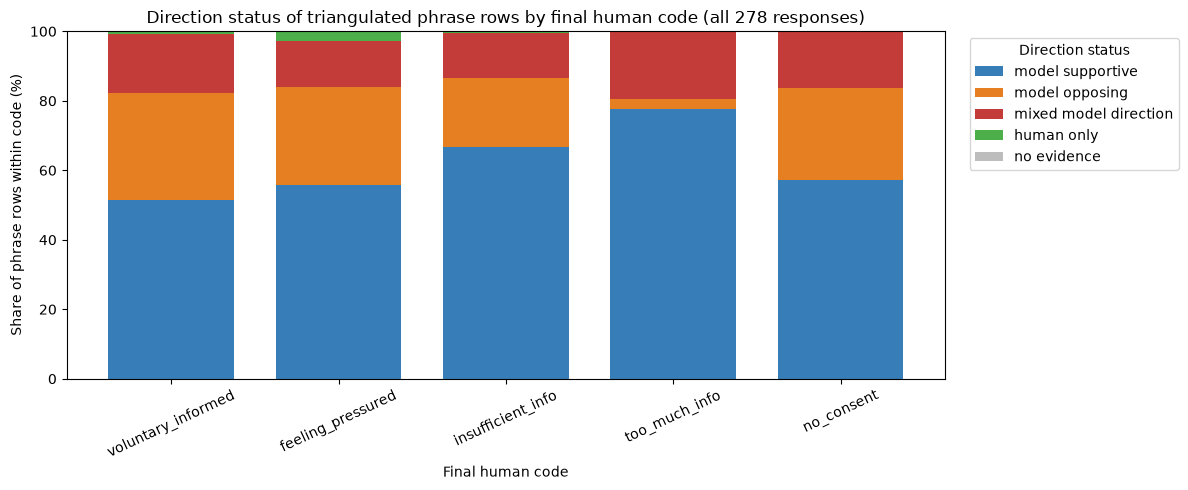

Saved: outputs\broad_candidate_revision\fig_triangulation_pattern_summary.png


In [11]:
# -- Full-corpus visual summary of triangulation direction patterns ------------
plot_summary = triangulation_pattern_summary.copy()
if len(plot_summary):
    direction_order = ['model supportive', 'model opposing', 'mixed model direction', 'human only', 'no evidence']
    plot_wide = (
        plot_summary.groupby(['true_code', 'evidence_direction_status'])['phrase_rows'].sum()
        .unstack(fill_value=0)
        .reindex(index=CODE_NAMES, fill_value=0)
        .reindex(columns=direction_order, fill_value=0)
    )
    plot_pct = plot_wide.div(plot_wide.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
    colors = ['#377eb8', '#e67e22', '#c43c39', '#4daf4a', '#bdbdbd']
    ax = plot_pct.plot(kind='bar', stacked=True, figsize=(12, 5), color=colors, width=0.75)
    ax.set_title('Direction status of triangulated phrase rows by final human code (all 278 responses)')
    ax.set_xlabel('Final human code')
    ax.set_ylabel('Share of phrase rows within code (%)')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Direction status', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_triangulation_pattern_summary.png', dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved: {OUTPUT_DIR / "fig_triangulation_pattern_summary.png"}')
else:
    print('No triangulation patterns available to plot.')


## 8. SetFit–human disagreement analysis

Most important for the thesis: where does the best NLP model fail, and why? This section uses the cross-validated SetFit MPNet predictions from Notebook 02, not zero-shot predictions.

In [12]:
# ── Find disagreements between SetFit MPNet and final qualitative codes ───────
if 'pred_setfit_oof' in dm_df.columns:
    dm_df['setfit_correct'] = dm_df['label'] == dm_df['pred_setfit_oof']
    disagreements = dm_df[~dm_df['setfit_correct']].copy()
    agreements    = dm_df[dm_df['setfit_correct']].copy()

    print(f'Agreements:    {len(agreements)} / {len(dm_df)} ({len(agreements)/len(dm_df)*100:.0f}%)')
    print(f'Disagreements: {len(disagreements)} / {len(dm_df)} ({len(disagreements)/len(dm_df)*100:.0f}%)')

    label_names = {v: k for k, v in DECISION_CODES.items()}
    disagreements['true_name'] = disagreements['label'].map(label_names)
    disagreements['pred_name'] = disagreements['pred_setfit_oof'].map(label_names)

    print('\nDisagreement patterns (true -> predicted):')
    patterns = disagreements.groupby(['true_name','pred_name']).size().sort_values(ascending=False)
    print(patterns.to_string())

    print('\n── Examples of each disagreement type ──')
    for (true_code, pred_code), count in patterns.head(8).items():
        examples = disagreements[
            (disagreements['true_name'] == true_code) &
            (disagreements['pred_name'] == pred_code)
        ]['response_text'].head(2)
        print(f'\nTRUE={true_code} -> PREDICTED={pred_code}  (n={count})')
        for ex in examples:
            print(f'  "{ex[:160]}"')
        print('  [Qualitative insight: what did the final human code capture that SetFit missed?]')
else:
    print('pred_setfit not found. Re-run Notebook 02 first.')


Agreements:    212 / 278 (76%)
Disagreements: 66 / 278 (24%)

Disagreement patterns (true -> predicted):
true_name           pred_name         
feeling_pressured   insufficient_info     21
insufficient_info   feeling_pressured     17
voluntary_informed  feeling_pressured      8
                    insufficient_info      7
feeling_pressured   voluntary_informed     3
no_consent          insufficient_info      3
                    feeling_pressured      2
insufficient_info   voluntary_informed     2
feeling_pressured   too_much_info          1
too_much_info       insufficient_info      1
                    feeling_pressured      1

── Examples of each disagreement type ──

TRUE=feeling_pressured -> PREDICTED=insufficient_info  (n=21)
  "After my birth. I was troubled by having had the sweeps. Even tho the birth was way better than my first. It was like the trauma from my first was unleashed aga"
  "There is lots to say but in general, the end of pregnancy is such a vulnerable time, eve

## 9. Save interpretability and triangulation artefacts


In [13]:
interp_outputs = {
    'analysis_scope': 'full decision-making corpus',
    'n_explained': len(explain_examples),
    'stratification_variables': ['true_code', 'OOF prediction correctness'],
    'lime_num_samples': LIME_NUM_SAMPLES,
    'shap_max_evals': SHAP_MAX_EVALS,
    'shap_values_serializable': shap_values_by_doc,
    'lime_explanations': lime_explanations,
    'agreement_df': agreement_df,
    'agreement_stratified_df': agreement_stratified_df,
    'explain_examples_idx': explain_examples,
    'token_shap_by_class': dict(token_shap_by_class),
    'phrase_shap_by_class': dict(phrase_shap_by_class),
    'phrase_shap_by_example': phrase_shap_by_example,
    'shap_phrase_vocabulary_size': len(SHAP_PHRASE_VOCAB),
    'phrase_vocabulary_policy': PHRASE_VOCABULARY_POLICY,
    'phrase_vocabulary_fingerprint': phrase_vocabulary_fingerprint,
    'common_phrase_vocabulary': sorted(SHAP_PHRASE_VOCAB),
    'human_evidence_rows_before_common_vocabulary_filter': human_evidence_rows_before_filter,
    'human_evidence_rows_after_common_vocabulary_filter': len(phrase_code_evidence_df),
    'explained_model': BEST_SETFIT_NAME,
    'explained_model_id': BEST_SETFIT_MODEL_ID,
    'explained_model_path': str(FINAL_SETFIT_MODEL_PATH),
    'domain_phrase_map_path': str(DOMAIN_PHRASE_MAP_PATH),
    'domain_phrases_used': DOMAIN_PHRASES,
    'explanation_target_type': 'final_model_predicted_class',
    'oof_explanation_policy': 'all explanations are final-model proxies; class agreement with OOF is reported only as alignment',
    'shap_phrase_aggregation_policy': 'contiguous spans from the common broad Notebook 03_0 2-4 gram candidate vocabulary; no stopword deletion before n-gram rebuilding',
    'triangulation_direction_policy': 'source_pattern records presence; directional_source_pattern/evidence_direction_status record supportive, opposing, or mixed model direction',
    'triangulated_phrase_evidence': triangulated_phrase_evidence_df,
    'triangulated_top_by_response': triangulated_top_by_response_df,
    'triangulation_pattern_summary': triangulation_pattern_summary,
}
with open(DATA_DIR / 'interpretability_results_broad_candidate_revision.pkl', 'wb') as f:
    pickle.dump(interp_outputs, f, protocol=pickle.HIGHEST_PROTOCOL)

agreement_df.to_csv(OUTPUT_DIR / 'shap_lime_agreement.csv', index=False)
agreement_stratified_df.to_csv(OUTPUT_DIR / 'shap_lime_agreement_stratified.csv', index=False)
triangulated_phrase_evidence_df.to_csv(OUTPUT_DIR / 'triangulated_phrase_evidence.csv', index=False)
triangulated_top_by_response_df.to_csv(OUTPUT_DIR / 'triangulated_phrase_evidence_top_by_response.csv', index=False)
triangulation_pattern_summary.to_csv(OUTPUT_DIR / 'triangulation_pattern_summary.csv', index=False)
dm_df[['response_id', 'source_row_id', 'pred_setfit_oof', 'pred_setfit_final_explainer', 'explanation_target_label', 'explanation_target_code', 'explanation_matches_oof_prediction', 'explanation_scope']].to_csv(OUTPUT_DIR / 'interpretability_prediction_scope.csv', index=False)

print('Saved full-corpus interpretability outputs:')
for name in [
    'interpretability_results_broad_candidate_revision.pkl', 'shap_lime_agreement.csv',
    'shap_lime_agreement_stratified.csv', 'triangulated_phrase_evidence.csv',
    'triangulated_phrase_evidence_top_by_response.csv',
    'triangulation_pattern_summary.csv', 'interpretability_prediction_scope.csv',
]:
    print(f'  {name}')
print(f'\nCoverage: {len(agreement_df)} / {len(DOCS)} responses have both LIME and SHAP agreement rows.')
rho_vals = pd.to_numeric(agreement_df['spearman_rho'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
print(f'Finite Spearman correlations: {len(rho_vals)} / {len(agreement_df)}')
print(f'Exact-overlap responses: {(agreement_df["n_common"] > 0).sum()} / {len(agreement_df)}')
print('\nProceed to Notebook 05 -- final evaluation and policy synthesis. Notebook 04 intervention tests remain out of scope.')


Saved full-corpus interpretability outputs:
  interpretability_results_broad_candidate_revision.pkl
  shap_lime_agreement.csv
  shap_lime_agreement_stratified.csv
  triangulated_phrase_evidence.csv
  triangulated_phrase_evidence_top_by_response.csv
  triangulation_pattern_summary.csv
  interpretability_prediction_scope.csv

Coverage: 278 / 278 responses have both LIME and SHAP agreement rows.
Finite Spearman correlations: 135 / 278
Exact-overlap responses: 254 / 278

Proceed to Notebook 05 -- final evaluation and policy synthesis. Notebook 04 intervention tests remain out of scope.
